In [20]:
import os
import math
import random
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("../images", exist_ok=True)

ALPH = string.ascii_uppercase
ALPH_SET = set(ALPH)

In [21]:
def clean_text(s: str) -> str:
    """Plaintext: keep only A-Z (uppercase)."""
    s = s.upper()
    return "".join(ch for ch in s if ch in ALPH_SET)

def clean_ciphertext(s: str, indicator: str = "|") -> str:
    """Ciphertext: keep A-Z plus the indicator marker."""
    s = s.upper()
    keep = ALPH_SET | {indicator}
    return "".join(ch for ch in s if ch in keep)

In [22]:
def freq_table(s: str) -> pd.DataFrame:
    s = clean_text(s)  # for frequency work, we ignore any indicator marker
    c = Counter(s)
    total = len(s) if len(s) else 1
    df = pd.DataFrame({"letter": list(ALPH)})
    df["n"] = df["letter"].map(lambda x: c.get(x, 0)).astype(int)
    df["p"] = df["n"] / total
    return df

def plot_freq(df: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.bar(df["letter"], df["p"])
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Relative Frequency")
    plt.tight_layout()
    return fig, ax

In [23]:
def make_mono_key(rng: random.Random) -> dict:
    perm = list(ALPH)
    rng.shuffle(perm)
    return {p: c for p, c in zip(ALPH, perm)}

def invert_key(key: dict) -> dict:
    return {v: k for k, v in key.items()}

def mono_encrypt(plaintext: str, key: dict) -> str:
    pt = clean_text(plaintext)
    return "".join(key[ch] for ch in pt)

def mono_decrypt(ciphertext: str, key: dict) -> str:
    inv = invert_key(key)
    ct = clean_text(ciphertext)
    return "".join(inv[ch] for ch in ct)

In [24]:
def rot_alpha(shift: int) -> str:
    """Inner disk alphabet is a rotation of A-Z."""
    shift %= 26
    return ALPH[shift:] + ALPH[:shift]

def shift_to_char(shift: int) -> str:
    """Encode shift 0..25 as A..Z."""
    return chr((shift % 26) + ord("A"))

def char_to_shift(ch: str) -> int:
    """Decode A..Z to shift 0..25."""
    ch = ch.upper()
    if ch not in ALPH_SET:
        raise ValueError("Shift character must be A-Z")
    return ord(ch) - ord("A")

In [25]:
def alberti_encrypt_periodic(plaintext: str, period: int = 20, shifts=None, rng=None):
    pt = clean_text(plaintext)
    if not pt:
        return {"ciphertext": "", "period": period, "shifts": []}

    n = len(pt)
    blocks = (n + period - 1) // period

    if shifts is None:
        if rng is None:
            rng = random.Random()
        shifts = [rng.randrange(26) for _ in range(blocks)]
    else:
        if len(shifts) < blocks:
            raise ValueError("shifts list shorter than number of blocks")

    out = []
    for b in range(blocks):
        inner = rot_alpha(shifts[b])
        start, end = b * period, min((b + 1) * period, n)
        for ch in pt[start:end]:
            out.append(inner[ord(ch) - 65])

    return {"ciphertext": "".join(out), "period": period, "shifts": shifts[:blocks]}

In [26]:
def alberti_encrypt_with_indicator(
    plaintext: str,
    period: int = 20,
    indicator: str = "|",
    shifts=None,
    rng=None
):
    """
    Each block starts with: indicator + shift-letter (A=0..Z=25)
    Then the ciphertext letters for up to `period` plaintext letters.
    """
    pt = clean_text(plaintext)
    if not pt:
        return {"ciphertext": "", "period": period, "shifts": [], "indicator": indicator}

    n = len(pt)
    blocks = (n + period - 1) // period

    if shifts is None:
        if rng is None:
            rng = random.Random()
        shifts = [rng.randrange(26) for _ in range(blocks)]
    else:
        if len(shifts) < blocks:
            raise ValueError("shifts list shorter than number of blocks")

    out = []
    for b in range(blocks):
        sh = shifts[b]
        inner = rot_alpha(sh)

        out.append(indicator)
        out.append(shift_to_char(sh))

        start, end = b * period, min((b + 1) * period, n)
        for ch in pt[start:end]:
            out.append(inner[ord(ch) - 65])

    return {"ciphertext": "".join(out), "period": period, "shifts": shifts[:blocks], "indicator": indicator}


def alberti_decrypt_with_indicator(ciphertext: str, period: int, indicator: str = "|") -> str:
    """
    Parse: |<shift-letter><block letters> repeated.
    Block letters end at next | or after `period` letters.
    """
    ct = clean_ciphertext(ciphertext, indicator=indicator)

    out = []
    i = 0
    while i < len(ct):
        # advance to next indicator if needed
        if ct[i] != indicator:
            i += 1
            continue

        if i + 1 >= len(ct):
            break  # indicator at end

        sh = char_to_shift(ct[i + 1])
        inner = rot_alpha(sh)
        inv = {inner[j]: ALPH[j] for j in range(26)}

        i += 2  # past indicator + shift letter

        read = 0
        while i < len(ct) and ct[i] != indicator and read < period:
            out.append(inv[ct[i]])
            i += 1
            read += 1

    return "".join(out)

In [27]:
plaintext = """
In the Renaissance, secrecy mattered. Alberti proposed changing alphabets during encryption.
This disrupts frequency analysis by flattening statistical patterns.
"""

pt = clean_text(plaintext)
len(pt), pt[:80]

(139,
 'INTHERENAISSANCESECRECYMATTEREDALBERTIPROPOSEDCHANGINGALPHABETSDURINGENCRYPTIONT')

In [28]:
rng = random.Random(42)

mono_key = make_mono_key(rng)
ct_mono = mono_encrypt(pt, mono_key)

# reset rng so comparisons are reproducible
rng = random.Random(42)
poly_noind = alberti_encrypt_periodic(pt, period=15, rng=rng)
ct_noind = poly_noind["ciphertext"]

rng = random.Random(42)
poly_ind = alberti_encrypt_with_indicator(pt, period=15, indicator="|", rng=rng)
ct_ind = poly_ind["ciphertext"]

print("Shifts:", poly_ind["shifts"])
print("\nNo-indicator sample:\n", ct_noind[:120])
print("\nWith-indicator sample:\n", ct_ind[:140])

Shifts: [20, 3, 0, 23, 8, 7, 7, 4, 23, 3]

No-indicator sample:
 CHNBYLYHUCMMUHWHVHFUHFBPDWWHUHDALBERTIPROPOSEAZEXKDFKDXIMEXYMBALCZQVOMVKZGXAPVUAOPZKPZYBWAZMYLXBLUJFHUHSFWMWFCJPEXXIRMRK

With-indicator sample:
 |UCHNBYLYHUCMMUHW|DHVHFUHFBPDWWHUH|ADALBERTIPROPOSE|XAZEXKDFKDXIMEXY|IMBALCZQVOMVKZGX|HAPVUAOPZKPZYBWA|HZMYLXBLUJFHUHSF|EWMWFCJPEXXIRMRK|XPQ


In [29]:
pt_back = alberti_decrypt_with_indicator(ct_ind, period=15, indicator="|")
print("Decryption matches plaintext:", pt_back == pt)

Decryption matches plaintext: True


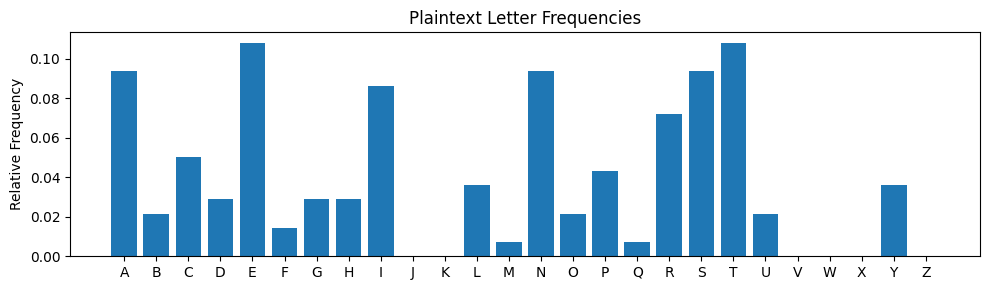

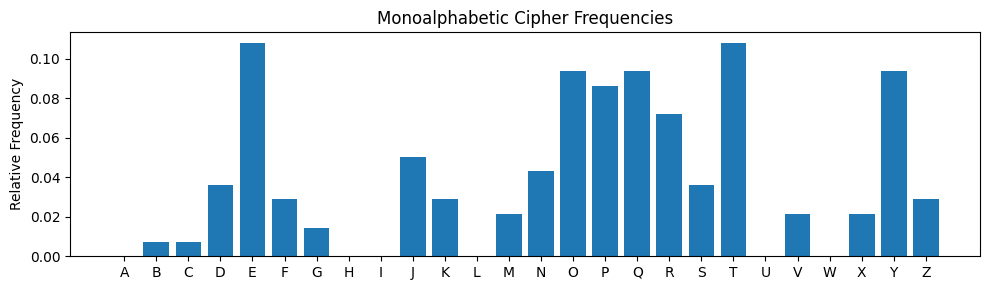

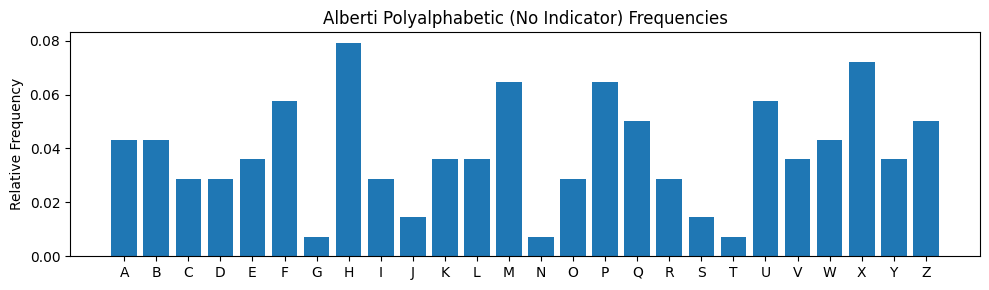

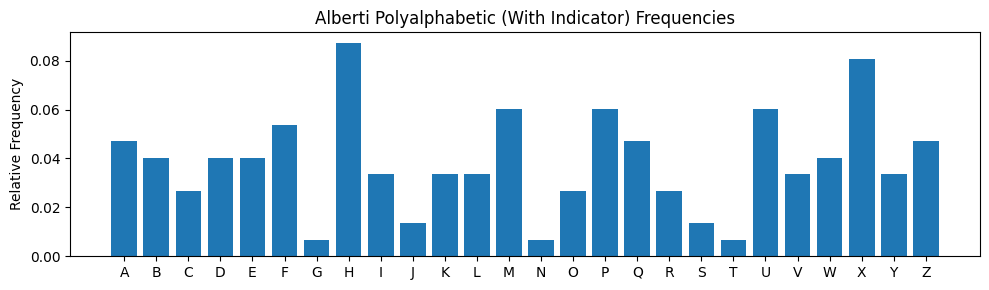

In [30]:
df_pt = freq_table(pt)
df_mono = freq_table(ct_mono)
df_alb_noind = freq_table(ct_noind)

# strip indicator marker before frequency
ct_ind_letters_only = ct_ind.replace("|", "")
df_alb_ind = freq_table(ct_ind_letters_only)

fig1, _ = plot_freq(df_pt, "Plaintext Letter Frequencies")
fig2, _ = plot_freq(df_mono, "Monoalphabetic Cipher Frequencies")
fig3, _ = plot_freq(df_alb_noind, "Alberti Polyalphabetic (No Indicator) Frequencies")
fig4, _ = plot_freq(df_alb_ind, "Alberti Polyalphabetic (With Indicator) Frequencies")

plt.show()

In [31]:
fig1.savefig("../images/freq_plaintext.png", dpi=160)
fig2.savefig("../images/freq_mono.png", dpi=160)
fig3.savefig("../images/freq_alberti_no_indicator.png", dpi=160)
fig4.savefig("../images/freq_alberti_with_indicator.png", dpi=160)

print("Saved:")
print(" - ../images/freq_plaintext.png")
print(" - ../images/freq_mono.png")
print(" - ../images/freq_alberti_no_indicator.png")
print(" - ../images/freq_alberti_with_indicator.png")

Saved:
 - ../images/freq_plaintext.png
 - ../images/freq_mono.png
 - ../images/freq_alberti_no_indicator.png
 - ../images/freq_alberti_with_indicator.png
